# Food Delivery Time Prediction

This project predicts food delivery time using machine learning techniques.
The analysis uses factors such as distance, weather conditions, traffic,
delivery person experience, order priority, and vehicle type.

The project includes data preprocessing, exploratory data analysis (EDA),
feature engineering, and machine learning models such as Linear Regression
and Logistic Regression to predict delivery time and classify deliveries
as fast or delayed.

Dataset Shape: (200, 15)
  Order_ID       Customer_Location     Restaurant_Location  Distance  \
0  ORD0001  (17.030479, 79.743077)  (12.358515, 85.100083)      1.57   
1  ORD0002  (15.398319, 86.639122)  (14.174874, 77.025606)     21.32   
2  ORD0003  (15.687342, 83.888808)  (19.594748, 82.048482)      6.95   
3  ORD0004  (20.415599, 78.046984)  (16.915906, 78.278698)     13.79   
4  ORD0005  (14.786904, 78.706532)  (15.206038, 86.203182)      6.72   

  Weather_Conditions Traffic_Conditions  Delivery_Person_Experience  \
0              Rainy             Medium                           4   
1             Cloudy             Medium                           8   
2              Snowy             Medium                           9   
3             Cloudy                Low                           2   
4              Rainy               High                           6   

  Order_Priority Order_Time Vehicle_Type  Restaurant_Rating  Customer_Rating  \
0         Medium  Afternoon        

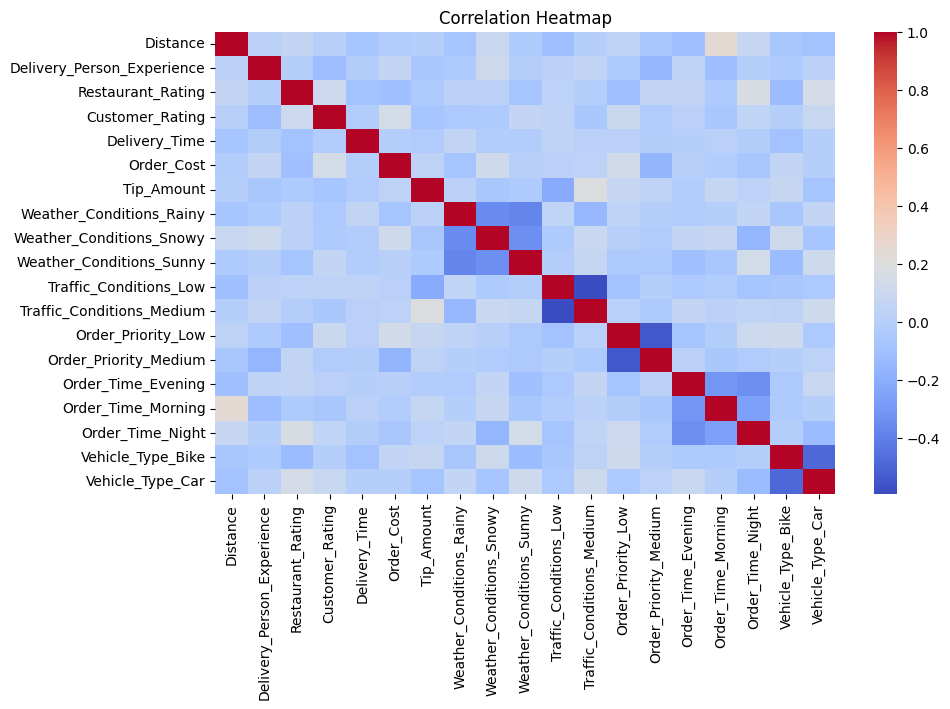

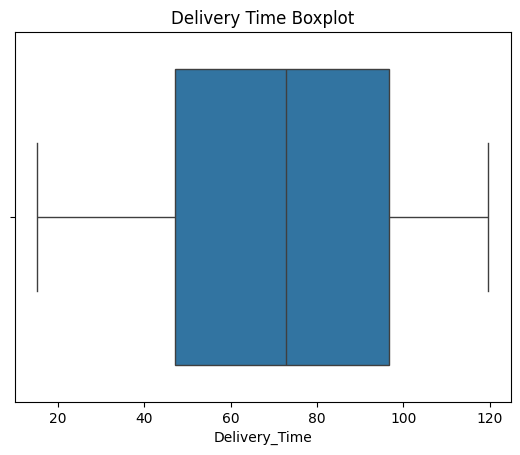


Linear Regression Results
MSE: 1021.9359676315065
MAE: 27.184522740542167
R2: -0.10492559254944922

Logistic Regression Results
Accuracy: 0.525
Precision: 0.6060606060606061
Recall: 0.7692307692307693
F1: 0.6779661016949152


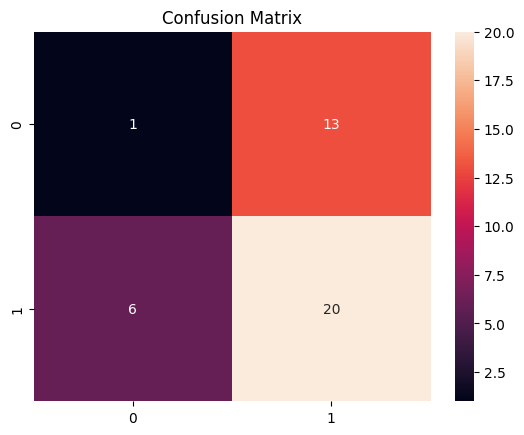

In [1]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ==============================
# 2. LOAD DATASET
# ==============================

df = pd.read_csv("Food_Delivery_Time_Prediction.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# ==============================
# 3. DATA PREPROCESSING
# ==============================

print("\nMissing Values:")
print(df.isnull().sum())

df = df.drop(columns=["Order_ID","Customer_Location","Restaurant_Location"])

df = pd.get_dummies(df, drop_first=True)

scaler = StandardScaler()

numeric_cols = [
    "Distance",
    "Delivery_Person_Experience",
    "Restaurant_Rating",
    "Customer_Rating",
    "Order_Cost",
    "Tip_Amount"
]

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("\nData after preprocessing:")
print(df.head())

# ==============================
# 4. EXPLORATORY DATA ANALYSIS
# ==============================

print("\nDescriptive Statistics:")
print(df.describe())

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

plt.figure()
sns.boxplot(x=df["Delivery_Time"])
plt.title("Delivery Time Boxplot")
plt.show()

# ==============================
# 5. LINEAR REGRESSION
# ==============================

X = df.drop("Delivery_Time", axis=1)
y = df["Delivery_Time"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("\nLinear Regression Results")
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

# ==============================
# 6. LOGISTIC REGRESSION
# ==============================

df["Delivery_Status"] = df["Delivery_Time"].apply(lambda x: 1 if x > 60 else 0)

X = df.drop(["Delivery_Time","Delivery_Status"], axis=1)
y = df["Delivery_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("\nLogistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

## Project Summary

This project analyzes food delivery data and predicts delivery time
based on operational factors such as distance, traffic, weather,
and delivery personnel experience.

Data preprocessing techniques such as encoding and feature scaling
were applied before building machine learning models.

Linear Regression was used to predict the exact delivery time,
while Logistic Regression was used to classify deliveries as fast
or delayed.

The results show that traffic conditions, distance, and delivery
experience significantly influence delivery time.